<a href="https://colab.research.google.com/github/Rabiatou08/DI-Bootcamp/blob/main/week5/Day2/Dailychallenges/defi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Défi quotidien : Classification avec des réseaux neuronaux dans TensorFlow

.Classification Binaire : Consiste à classer des données dans l'une de deux catégories exclusives (Oui/Non).
Exemple : Prédire si un e-mail est un "Spam" (1) ou "Non-Spam" (0).

.Classification Multiclasse : Consiste à classer des données dans une seule catégorie parmi trois choix possibles ou plus.
Exemple : Classer une image d'animal comme étant soit un "Chien", soit un "Chat", soit un "Oiseau".

.Classification Multi-étiquettes (Multi-label) : Consiste à attribuer simultanément une ou plusieurs étiquettes non exclusives à une même donnée.
Exemple : Taguer un article de presse avec les étiquettes "Politique", "Économie" et "Europe" en même temps.

--- Étape 2 : Génération et visualisation des cercles ---
Forme de X (coordonnées) : (1000, 2)
Forme de y (classes)     : (1000,)


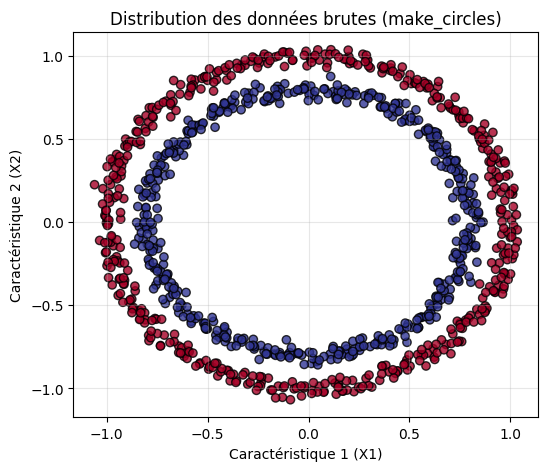


--- Étape 3, 4, 6 : Construction et entraînement du modèle final ---

--- Étape 8 : Évaluation sur l'ensemble de test ---
Perte sur le jeu de test : 0.0041
Exactitude sur le jeu de test (Accuracy) : 100.00 %


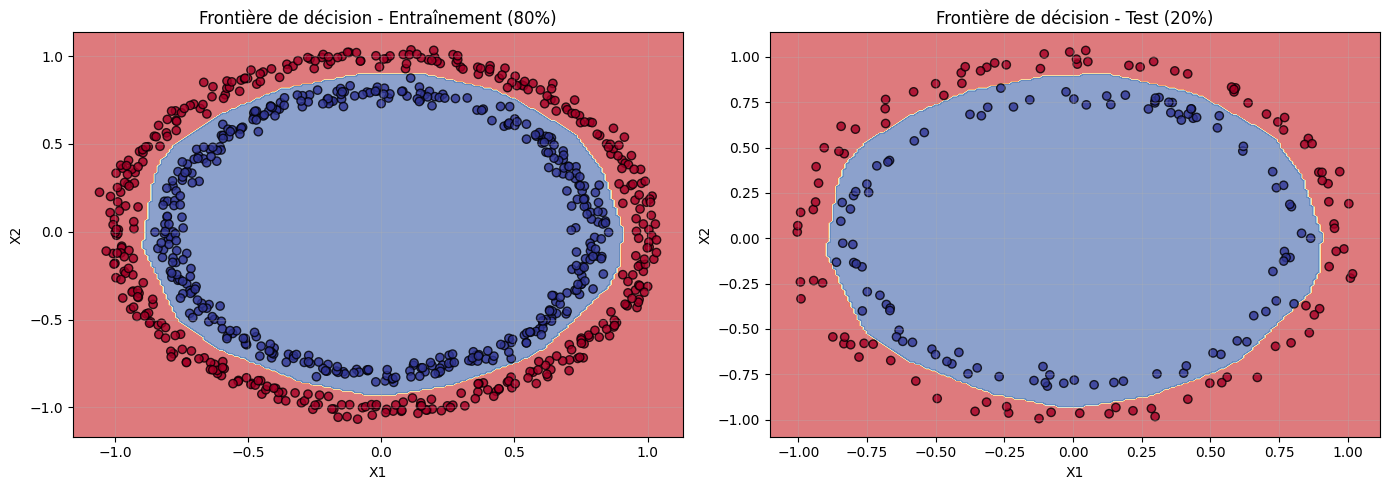

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# =====================================================================
# 2. CONFIGURATION ET VISUALISATION DU JEU DE DONNÉES
# =====================================================================
print("--- Étape 2 : Génération et visualisation des cercles ---")
samples = 1000
X, y = make_circles(samples, noise=0.03, random_state=42)

print(f"Forme de X (coordonnées) : {X.shape}")
print(f"Forme de y (classes)     : {y.shape}")

# Nuage de points initial
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='k', alpha=0.8)
plt.title("Distribution des données brutes (make_circles)")
plt.xlabel("Caractéristique 1 (X1)")
plt.ylabel("Caractéristique 2 (X2)")
plt.grid(True, alpha=0.3)
plt.show()

# =====================================================================
# 5. DÉFINITION DE LA FONCTION DE FRONTIÈRE DE DÉCISION
# =====================================================================
def plot_decision_boundary(model, X, y, title="Frontière de décision"):
    """Trace la frontière de décision géométrique apprise par le modèle."""
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    # Prédictions sur toute la surface de la grille
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid_points, verbose=0)

    # On arrondit à la classe binaire (0 ou 1)
    if preds.shape[1] > 1:
        preds = np.argmax(preds, axis=1)
    else:
        preds = np.round(preds)

    preds = preds.reshape(xx.shape)

    # Tracé des contours colorés
    plt.contourf(xx, yy, preds, cmap=plt.cm.RdYlBu, alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='k', alpha=0.8)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(title)
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.grid(True, alpha=0.3)

# =====================================================================
# 7. DIVISION DES DONNÉES EN ENSEMBLES D'ENTRAÎNEMENT ET DE TEST
# =====================================================================
# Répartition stricte 80% entraînement et 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =====================================================================
# 3, 4, 6. ARCHITECTURE, FUNCTIONS D'ACTIVATION ET ENTRAÎNEMENT
# =====================================================================
print("\n--- Étape 3, 4, 6 : Construction et entraînement du modèle final ---")

tf.random.set_seed(42)

# Création d'un modèle séquentiel propre Keras 3
model_final = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),                 # Couche d'entrée explicite
    tf.keras.layers.Dense(16, activation='relu'),      # Couche 1 avec ReLU
    tf.keras.layers.Dense(8, activation='relu'),       # Couche 2 avec ReLU
    tf.keras.layers.Dense(1, activation='sigmoid')     # Sortie avec Sigmoid (en anglais)
])

# Compilation avec l'optimiseur Adam et la perte d'entropie croisée binaire
model_final.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entraînement sur 100 époques (silencieux)
history = model_final.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    verbose=0
)

# =====================================================================
# 8. ÉVALUATION ET VISUALISATION DES PERFORMANCES FINALES
# =====================================================================
print("\n--- Étape 8 : Évaluation sur l'ensemble de test ---")
test_loss, test_acc = model_final.evaluate(X_test, y_test, verbose=0)
print("="*60)
print(f"Perte sur le jeu de test : {test_loss:.4f}")
print(f"Exactitude sur le jeu de test (Accuracy) : {test_acc*100:.2f} %")
print("="*60)

# Affichage des frontières de décision comparatives (Train vs Test)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plot_decision_boundary(model_final, X_train, y_train, title="Frontière de décision - Entraînement (80%)")

plt.subplot(1, 2, 2)
plot_decision_boundary(model_final, X_test, y_test, title="Frontière de décision - Test (20%)")

plt.tight_layout()
plt.show()


1. Ce que j'ai appris : Une seule couche linéaire sans fonction d'activation est incapable de séparer des cercles imbriqués, car elle ne trace que des lignes droites. L'introduction de couches masquées denses associées à des fonctions d'activation non linéaires comme ReLU permet au réseau de tordre l'espace mathématique pour épouser parfaitement les formes géométriques complexes. La fonction Sigmoïde en sortie convertit quant à elle le signal en une probabilité binaire propre comprise entre 0 et 1.


2. Importance de la visualisation et du réglage des hyperparamètres : Le recours à des fonctions graphiques comme plot_decision_boundary() est capital pour vérifier visuellement que le réseau ne fait pas de surapprentissage. Ajuster le nombre de neurones, passer d'un optimiseur SGD classique à Adam et augmenter le nombre d'époques sont des actions indispensables pour aider le modèle à converger efficacement vers une précision cible proche de 100 %.